In [2]:
import pandas as pd

df = pd.read_csv('inference_tartaglia_40.csv')
unique_combinations = df[['data', 'echo']].drop_duplicates()


In [3]:
import numpy as np
from tqdm import tqdm
import os
# Get unique combinations of subfolder, patient_folder, dicom, and vista
unique_combinations = df[['data', 'echo']].drop_duplicates()

# Initialize output data list
output_data = []

# Iterate over the unique combinations to optimize the loop
for idx, row in tqdm(unique_combinations.iterrows(), total=len(unique_combinations)):
    data = row['data']
    echo = row['echo']

    # Filtrar el dataframe para el estudio actual
    filtered_df = df[(df['data'] == data) & 
                     (df['echo'] == echo) ]

    # Verificar que haya datos en filtered_df
    if filtered_df.empty:
        continue

    # Identificar si la vista es 3ch, plax o psax_aov
    if 'data_3ch' in filtered_df['data'].values:
        filtered_df = filtered_df[filtered_df['vista'] == '3c']
        base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\3ch'
    elif 'data_plax' in filtered_df['data'].values:
        filtered_df = filtered_df[filtered_df['vista'] == 'plax']
        base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\plax'
    else:
        filtered_df = filtered_df[filtered_df['vista'] == 'psax_aov']
        base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\psax'

    # Frame específico para cargar
    frame_name = 'frame_0000.npy'

    # Cargar el frame_0000
    frame_path = os.path.join(base_dir, echo, frame_name)
    
    try:
        frame = np.load(frame_path)  # Cargar la imagen como numpy array
    except FileNotFoundError:
        print(f'Error load frame: {data}, {echo}')
        continue

    # Obtener las dimensiones actuales del frame
    frame_height, frame_width = frame.shape
    
    # Definir las dimensiones originales (de donde provienen las coordenadas)
    original_height, original_width = 256, 256  # Este es el tamaño en el que fueron predichas las cajas

    # Factor de escalado para las coordenadas
    scale_x = frame_width / original_width
    scale_y = frame_height / original_height

    # Crear la matriz de densidad del mismo tamaño que el frame
    density_map = np.zeros_like(frame)

    # Recorrer todas las cajas de este estudio y calcular la densidad
    for index, row in filtered_df.iterrows():
        p1 = eval(row['p1'])  # Las coordenadas ya se han convertido en listas
        p2 = eval(row['p2'])

        # Escalar las coordenadas de las cajas
        p1_scaled = [int(p1[0] * scale_x), int(p1[1] * scale_y)]
        p2_scaled = [int(p2[0] * scale_x), int(p2[1] * scale_y)]

        # Aumentar el valor de densidad dentro del área del recuadro
        density_map[p1_scaled[1]:p2_scaled[1], p1_scaled[0]:p2_scaled[0]] += 1

    # Definir el umbral de densidad como el 10% del número total de frames
    threshold = len(filtered_df) * 0.10

    # Encontrar las coordenadas de los píxeles que cumplen con el umbral de densidad
    y_coords, x_coords = np.where(density_map >= threshold)

    # Verificar que haya coordenadas que cumplan con el umbral
    if not len(x_coords) or not len(y_coords):
        continue

    # Encontrar el rectángulo que envuelve la región con densidad suficiente
    min_x, max_x = min(x_coords), max(x_coords)
    min_y, max_y = min(y_coords), max(y_coords)

    # Añadir un margen del 5%
    margin = 0.1
    x_margin = int((max_x - min_x) * margin)
    y_margin = int((max_y - min_y) * margin)

    # Aplicar el margen y asegurarse de que no se salga de los límites del frame
    min_x = max(0, min_x - x_margin)
    max_x = min(frame_width, max_x + x_margin)
    min_y = max(0, min_y - y_margin)
    max_y = min(frame_height, max_y + y_margin)

    # Convertir el rectángulo en un cuadrado
    rect_width = max_x - min_x
    rect_height = max_y - min_y
    max_side = max(rect_width, rect_height)

    # Ajustar el rectángulo para que sea un cuadrado
    if rect_width < max_side:
        diff = max_side - rect_width
        min_x = max(0, min_x - diff // 2)
        max_x = min(frame_width, max_x + diff // 2)
    if rect_height < max_side:
        diff = max_side - rect_height
        min_y = max(0, min_y - diff // 2)
        max_y = min(frame_height, max_y + diff // 2)

    # Guardar los resultados en la lista de datos
    try:
        output_data.append({
            'data': filtered_df['data'].iloc[0],
            'echo': echo,
            'p1_new': (min_x, max_y),  # Nueva esquina superior izquierda
            'p2_new': (max_x, min_y)   # Nueva esquina inferior derecha
        })
    except IndexError:
        output_data.append({
            'data': data,
            'echo': echo,
            'p1_new': (-1, -1),  # Nueva esquina superior izquierda
            'p2_new': (-1, -1)   # Nueva esquina inferior derecha
        })
        print(f"Error procesando: {data}, {echo}")
        continue

# Crear un nuevo DataFrame con los resultados
output_df = pd.DataFrame(output_data)

# Guardar el DataFrame en un archivo CSV
output_file_path = 'inference_tartaglia_40_square.csv'
output_df.to_csv(output_file_path, index=False)

  0%|          | 0/265 [00:00<?, ?it/s]

 41%|████      | 108/265 [00:06<00:09, 15.83it/s]

Error procesando: data_3ch, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708099302.328.30


 42%|████▏     | 110/265 [00:06<00:12, 12.28it/s]

Error procesando: data_3ch, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708100299.312.90
Error procesando: data_3ch, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708100300.765.94


...

 84%|████████▍ | 222/265 [00:13<00:02, 15.84it/s]

Error procesando: data_psax, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708110050.671.85
Error procesando: data_psax, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708110072.218.6


 92%|█████████▏| 244/265 [00:14<00:01, 15.15it/s]

Error procesando: data_psax, 1.2.826.0.1.3680043.2.135.738651.68951324.7.1708111621.0.37


100%|██████████| 265/265 [00:16<00:00, 16.44it/s]


In [4]:
output_df

,data,echo,p1_new,p2_new
0,data_plax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(218, 293)","(374, 138)"
1,data_plax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(213, 271)","(361, 123)"
2,data_plax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(206, 347)","(341, 212)"
3,data_plax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(202, 316)","(330, 188)"
4,data_plax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(206, 356)","(437, 126)"
...,...,...,...,...
260,data_psax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(139, 322)","(315, 146)"
261,data_psax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(246, 535)","(486, 295)"
262,data_psax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(233, 500)","(449, 284)"
263,data_psax,1.2.826.0.1.3680043.2.135.738651.68951324.7.17...,"(240, 483)","(463, 259)"


In [5]:
import pandas as pd
import ast

# Load the adjusted CSV into a DataFrame
df = pd.read_csv('inference_tartaglia_40_square.csv')

# Convert p1_new and p2_new from strings to tuples
df['p1_new'] = df['p1_new'].apply(ast.literal_eval)
df['p2_new'] = df['p2_new'].apply(ast.literal_eval)

# Function to adjust the width and height to at least 128 pixels
def adjust_to_min_128(p1, p2):
    width = abs(p2[0] - p1[0])
    height = abs(p2[1] - p1[1])

    # Adjust width if less than 128
    if width < 128:
        width_diff = 128 - width
        p1_new_x = p1[0] - width_diff // 2
        p2_new_x = p2[0] + width_diff // 2

        # In case of odd difference, adjust one side by one extra pixel
        if width_diff % 2 != 0:
            p2_new_x += 1  # Add remaining pixel to p2 (right side)

        p1 = (p1_new_x, p1[1])
        p2 = (p2_new_x, p2[1])

    # Adjust height if less than 128
    if height < 128:
        height_diff = 128 - height
        p1_new_y = p1[1] + height_diff // 2
        p2_new_y = p2[1] - height_diff // 2

        # In case of odd difference, adjust one side by one extra pixel
        if height_diff % 2 != 0:
            p2_new_y -= 1  # Add remaining pixel to p2 (bottom side)

        p1 = (p1[0], p1_new_y)
        p2 = (p2[0], p2_new_y)

    return p1, p2

# Iterate over the DataFrame and adjust for cases where width or height is less than 128
for idx, row in df.iterrows():
    p1 = row['p1_new']
    p2 = row['p2_new']

    # Omit cases where p1 or p2 are (-1, -1)
    if p1 == (-1, -1) or p2 == (-1, -1):
        continue

    # Calculate width and height
    width = abs(p2[0] - p1[0])
    height = abs(p2[1] - p1[1])

    # Adjust if width or height is less than 128
    if width < 128 or height < 128:
        p1_new, p2_new = adjust_to_min_128(p1, p2)
        
        # Calculate new width and height after adjustment
        new_width = abs(p2_new[0] - p1_new[0])
        new_height = abs(p2_new[1] - p1_new[1])
        
        # Print the old and new coordinates, width, and height
        print(f"Old p1: {p1}, Old p2: {p2}, New p1: {p1_new}, New p2: {p2_new}, Old width: {width}, Old height: {height}, New width: {new_width}, New height: {new_height}")
        
        # Update the DataFrame with adjusted coordinates
        df.at[idx, 'p1_new'] = p1_new
        df.at[idx, 'p2_new'] = p2_new

# Save the updated DataFrame to a new CSV
df.to_csv('inference_tartaglia_40_square_corrected.csv', index=False)


Old p1: (210, 319), Old p2: (336, 193), New p1: (209, 320), New p2: (337, 192), Old width: 126, Old height: 126, New width: 128, New height: 128
Old p1: (247, 331), Old p2: (375, 204), New p1: (247, 331), New p2: (375, 203), Old width: 128, Old height: 127, New width: 128, New height: 128
Old p1: (260, 335), Old p2: (381, 213), New p1: (257, 338), New p2: (385, 210), Old width: 121, Old height: 122, New width: 128, New height: 128
Old p1: (288, 264), Old p2: (410, 141), New p1: (285, 266), New p2: (413, 138), Old width: 122, Old height: 123, New width: 128, New height: 128
Old p1: (219, 289), Old p2: (339, 168), New p1: (215, 292), New p2: (343, 164), Old width: 120, Old height: 121, New width: 128, New height: 128
Old p1: (239, 282), Old p2: (353, 167), New p1: (232, 288), New p2: (360, 160), Old width: 114, Old height: 115, New width: 128, New height: 128
Old p1: (264, 364), Old p2: (374, 255), New p1: (255, 373), New p2: (383, 245), Old width: 110, Old height: 109, New width: 128, N

In [6]:
import os
import numpy as np
import csv
import ast
import pandas as pd

# Función para calcular el ancho y la altura a partir de dos puntos
def calcular_dimensiones(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    ancho = abs(x2 - x1)
    altura = abs(y2 - y1)
    return ancho, altura

# Función para ajustar las dimensiones si la diferencia entre ancho y altura es <= 5
def ajustar_a_cuadrado(p1, p2, ancho, altura, frame_height, frame_width):
    if abs(ancho - altura) <= 5:
        # Ajustar el ancho y la altura al máximo entre ambos para convertir en cuadrado
        nuevo_tamano = max(ancho, altura)
        x1, y1 = p1
        x2, y2 = p2
        if ancho > altura:
            y2 = y1 + nuevo_tamano if y2 > y1 else y1 - nuevo_tamano
        else:
            x2 = x1 + nuevo_tamano if x2 > x1 else x1 - nuevo_tamano
        p2_corregido = (x2, y2)
        return p2_corregido
    else:
        # Si la diferencia es mayor de 5, ajustamos para que sea cuadrado reduciendo el lado más largo
        return ajustar_por_borde(p1, p2, ancho, altura, frame_height, frame_width)

# Función para ajustar cuando la diferencia entre ancho y altura es mayor de 5
def ajustar_por_borde(p1, p2, ancho, altura, frame_height, frame_width):
    x1, y1 = p1
    x2, y2 = p2

    # Queremos que el cuadrado quede dentro de la imagen
    nuevo_tamano = min(ancho, altura)

    # Si el ancho es mayor, reducimos el ancho manteniendo las coordenadas dentro del borde
    if ancho > altura:
        if x2 > x1:
            x2 = min(x1 + nuevo_tamano, frame_width)
        else:
            x2 = max(x1 - nuevo_tamano, 0)
    else:  # Si la altura es mayor, reducimos la altura manteniendo las coordenadas dentro del borde
        if y2 > y1:
            y2 = min(y1 + nuevo_tamano, frame_height)
        else:
            y2 = max(y1 - nuevo_tamano, 0)

    return (x2, y2)

# Leer el archivo CSV y corregir las dimensiones
input_file = 'inference_tartaglia_40_square_corrected.csv'
output_file = 'inference_tartaglia_40_square_corrected_def.csv'
df = pd.read_csv(input_file)

with open(input_file, 'r') as csvfile, open(output_file, 'w', newline='') as outfile:
    reader = csv.DictReader(csvfile)
    writer = csv.writer(outfile)

    # Escribir encabezado
    writer.writerow(reader.fieldnames)

    # Procesar cada fila del archivo CSV
    for row in reader:
        data = row['data']
        echo = row['echo']

        # Filtrar el DataFrame para el estudio actual (usando df)
        filtered_df = df[(df['data'] == data) & (df['echo'] == echo)]

        # Verificar si existen datos en filtered_df
        if filtered_df.empty:
            print(f"No se encontraron datos para: data={data}, echo={echo}")
            continue

        # Identificar la vista (3ch, plax o psax_aov) y ruta base
        if 'data_3ch' in filtered_df['data'].values:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\3ch'
        elif 'data_plax' in filtered_df['data'].values:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\plax'
        else:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\tartaglia_db\cropped_frames\256_256\psax'

        # Nombre del frame específico
        frame_name = 'frame_0000.npy'

        # Ruta completa al frame
        frame_path = os.path.join(base_dir,  echo, frame_name)

        try:
            # Cargar el frame y obtener sus dimensiones (altura y ancho)
            frame = np.load(frame_path)
            frame_height, frame_width = frame.shape

            if frame_height<frame_width:
                frame_width = frame_height
            else:
                frame_height = frame_width

            print(f"Dimensiones del frame (data={data}, echo={echo}): {frame_height}x{frame_width}")

            # Procesar las coordenadas p1_new y p2_new
            p1_new = ast.literal_eval(row['p1_new'])
            p2_new = ast.literal_eval(row['p2_new'])

            # Calcular ancho y altura
            ancho, altura = calcular_dimensiones(p1_new, p2_new)

            # Ajustar p2_new si es necesario, pasando frame_height y frame_width
            p2_new_corregido = ajustar_a_cuadrado(p1_new, p2_new, ancho, altura, frame_height, frame_width)

            # Volver a calcular el ancho y la altura después de la corrección
            ancho_corregido, altura_corregido = calcular_dimensiones(p1_new, p2_new_corregido)

            # Si la diferencia es mayor de 5, aplicar ajuste por borde
            if abs(ancho_corregido - altura_corregido) > 5:
                p2_new_corregido = ajustar_por_borde(p1_new, p2_new_corregido, ancho_corregido, altura_corregido, frame_height, frame_width)

            # Escribir la nueva fila con las coordenadas corregidas
            writer.writerow([data,  echo, p1_new, p2_new_corregido])

        except FileNotFoundError:
            print(f"Error al cargar el frame: {frame_path}")


Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708003304.297.54): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708003303.891.52): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708006981.204.51): 534x534
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708006981.313.55): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708006982.391.57): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708006983.454.58): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708006993.438.94): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.738651.68951324.7.1708008408.719.53): 480x480
Dimensiones del frame (data=data_plax, echo=1.2.826.0.1.3680043.2.135.73

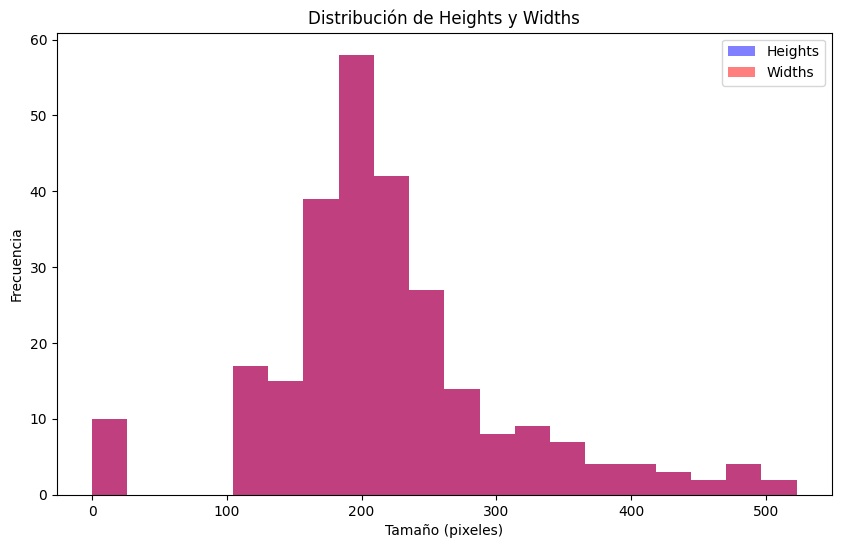

No se encontraron discrepancias entre height y width.


In [7]:
import csv
import ast
import matplotlib.pyplot as plt

# Leer el archivo CSV con las coordenadas corregidas
input_file = 'inference_tartaglia_40_square_corrected_def.csv'

# Inicializar listas para almacenar alturas y anchos
heights = []
widths = []
discrepancies = []

# Función para calcular el ancho y la altura a partir de dos puntos
def calcular_dimensiones(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    ancho = abs(x2 - x1)
    altura = abs(y2 - y1)
    return ancho, altura

# Leer el archivo CSV y procesar las dimensiones
with open(input_file, 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        # Procesar las coordenadas p1_new y p2_new
        p1_new = ast.literal_eval(row['p1_new'])
        p2_new = ast.literal_eval(row['p2_new'])

        # Calcular ancho y altura
        ancho, altura = calcular_dimensiones(p1_new, p2_new)

        # Almacenar en listas
        heights.append(altura)
        widths.append(ancho)

        # Verificar si hay discrepancia entre altura y ancho
        if ancho != altura:
            discrepancies.append((row['data'], row['echo'], ancho, altura))

# Graficar la distribución de alturas y anchos
plt.figure(figsize=(10, 6))
plt.hist(heights, bins=20, alpha=0.5, label='Heights', color='blue')
plt.hist(widths, bins=20, alpha=0.5, label='Widths', color='red')
plt.title('Distribución de Heights y Widths')
plt.xlabel('Tamaño (pixeles)')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')
plt.show()

# Imprimir las discrepancias si las hay
if discrepancies:
    print("Discrepancias encontradas entre height y width:")
    for data, echo, ancho, altura in discrepancies:
        print(f"Data: {data}, Echo: {echo}, Width: {ancho}, Height: {altura}")
else:
    print("No se encontraron discrepancias entre height y width.")
